In [ ]:
!pip install kagglehub cryptography tensorflow scikit-learn pyarrow

import os
import json
import hashlib
import numpy as np
import pandas as pd
import kagglehub

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import classification_report

import tensorflow as tf
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import BatchNormalization, Dropout
from tensorflow.keras.layers import Bidirectional, LSTM
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

from cryptography.hazmat.primitives.asymmetric import ec
from cryptography.hazmat.primitives.ciphers.aead import AESGCM

In [ ]:
# -------------------------
# LOAD UNSW DATASET
# -------------------------

path_unsw = kagglehub.dataset_download("mrwellsdavid/unsw-nb15")

train_unsw = pd.read_csv(os.path.join(path_unsw,"UNSW_NB15_training-set.csv"))
test_unsw = pd.read_csv(os.path.join(path_unsw,"UNSW_NB15_testing-set.csv"))

unsw = pd.concat([train_unsw,test_unsw],ignore_index=True)

unsw.rename(columns={"label":"Label"},inplace=True)

print("UNSW shape:",unsw.shape)

# -------------------------
# LOAD CICIDS DATASET
# -------------------------

path_cicids = kagglehub.dataset_download("dhoogla/cicids2017")

dfs=[]

for f in os.listdir(path_cicids):

    if f.endswith(".parquet"):

        df=pd.read_parquet(os.path.join(path_cicids,f))
        dfs.append(df)

cicids=pd.concat(dfs)

print("CICIDS shape:",cicids.shape)

Using Colab cache for faster access to the 'unsw-nb15' dataset.
UNSW shape: (257673, 45)
Using Colab cache for faster access to the 'cicids2017' dataset.
CICIDS shape: (2313810, 78)


In [ ]:
# -------------------------
# PREPROCESS UNSW DATASET
# -------------------------

data=unsw.copy()

# encode categorical columns
for col in data.columns:

    if data[col].dtype=="object":

        le=LabelEncoder()

        data[col]=le.fit_transform(data[col].astype(str))

# clean values
data.replace([np.inf,-np.inf],np.nan,inplace=True)
data.fillna(0,inplace=True)

# reduce dataset size for training speed
data=data.sample(150000,random_state=42)

X=data.drop("Label",axis=1)
y=data["Label"]

# normalize
scaler=StandardScaler()
X=scaler.fit_transform(X)

# reshape for CNN
X=X.reshape(X.shape[0],X.shape[1],1)

print("Training features:",X.shape)

# -------------------------
# BUILD CNN + BiLSTM MODEL
# -------------------------

def build_model(input_shape):

    inputs=Input(shape=input_shape)

    x=Conv1D(64,3,activation='relu')(inputs)
    x=BatchNormalization()(x)
    x=MaxPooling1D(2)(x)
    x=Dropout(0.3)(x)

    x=Conv1D(128,3,activation='relu')(x)
    x=BatchNormalization()(x)
    x=MaxPooling1D(2)(x)
    x=Dropout(0.3)(x)

    x=Bidirectional(LSTM(64))(x)

    x=Dense(64,activation='relu')(x)
    x=Dropout(0.4)(x)

    outputs=Dense(1,activation='sigmoid')(x)

    model=Model(inputs,outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


# -------------------------
# 5-FOLD CROSS VALIDATION
# -------------------------

kf=KFold(n_splits=5,shuffle=True,random_state=42)

fold=1
scores=[]

for train_idx,val_idx in kf.split(X):

    print("\nFold:",fold)

    X_train,X_val=X[train_idx],X[val_idx]
    y_train,y_val=y.iloc[train_idx],y.iloc[val_idx]

    model=build_model((X.shape[1],1))

    early=EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    history = model.fit( # Capture the history object
        X_train,
        y_train,
        epochs=8,
        batch_size=512,
        validation_data=(X_val,y_val),
        callbacks=[early]
    )

    loss,acc=model.evaluate(X_val,y_val)

    print("Accuracy:",acc)

    scores.append(acc)

    fold+=1

print("\nAverage accuracy:",np.mean(scores))

Training features: (150000, 44, 1)

Fold: 1
Epoch 1/8
235/235 ━━━━━━━━━━━━━━━━━━━━ 51s 189ms/step - accuracy: 0.8727 - loss: 0.2852 - val_accuracy: 0.7690 - val_loss: 0.5382
Epoch 2/8
235/235 ━━━━━━━━━━━━━━━━━━━━ 83s 193ms/step - accuracy: 0.9341 - loss: 0.1471 - val_accuracy: 0.9340 - val_loss: 0.1611
Epoch 3/8
235/235 ━━━━━━━━━━━━━━━━━━━━ 80s 186ms/step - accuracy: 0.9412 - loss: 0.1310 - val_accuracy: 0.9501 - val_loss: 0.1089
Epoch 4/8
235/235 ━━━━━━━━━━━━━━━━━━━━ 45s 191ms/step - accuracy: 0.9486 - loss: 0.1170 - val_accuracy: 0.9616 - val_loss: 0.0928
Epoch 5/8
235/235 ━━━━━━━━━━━━━━━━━━━━ 81s 187ms/step - accuracy: 0.9564 - loss: 0.1031 - val_accuracy: 0.9615 - val_loss: 0.0864
Epoch 6/8
235/235 ━━━━━━━━━━━━━━━━━━━━ 45s 192ms/step - accuracy: 0.9583 - loss: 0.0978 - val_accuracy: 0.9643 - val_loss: 0.0839
Epoch 7/8
235/235 ━━━━━━━━━━━━━━━━━━━━ 44s 186ms/step - accuracy: 0.9616 - loss: 0.0926 - val_accuracy: 0.9671 - val_loss: 0.0796
Epoch 8/8
235/235 ━━━━━━━━━━━━━━━━━━━━ 82s 187

In [ ]:
# -------------------------
# ECDH HANDSHAKE
# -------------------------

sender_private=ec.generate_private_key(ec.SECP256R1())
receiver_private=ec.generate_private_key(ec.SECP256R1())

shared_secret=sender_private.exchange(
    ec.ECDH(),
    receiver_private.public_key()
)

# -------------------------
# KEY DERIVATION
# -------------------------

aes_key=hashlib.sha256(shared_secret).digest()[:16]

def encrypt_packet(data):

    aes=AESGCM(aes_key)

    nonce=os.urandom(12)

    return aes.encrypt(nonce,data.encode(),None)

# -------------------------
# THREAT ENGINE
# -------------------------

def detect_threat():

    sample = X_val[np.random.randint(len(X_val))].reshape(1,X_val.shape[1],1)

    raw_prob = model.predict(sample)[0][0]

    prob = float(np.clip(raw_prob,0.05,0.95))

    if prob < 0.3:
        level="LOW"
        action="Normal Encryption"

    elif prob < 0.7:
        level="MEDIUM"
        action="Stronger Encryption"

    else:
        level="HIGH"
        action="Key Regeneration"

    return prob, level, action

# -------------------------
# SIMULATION
# -------------------------

for i in range(5):

    packet=json.dumps({

        "patient_id":np.random.randint(1000),
        "heart_rate":np.random.randint(60,120),
        "spo2":np.random.randint(92,100)

    })

    # Removed redundant sample and prob calculation, now calling detect_threat directly
    prob, level, action = detect_threat()

    encrypted=encrypt_packet(packet)

    print("\nThreat Probability:",round(prob,4))
    print("Threat Level:",level)
    print("Action:",action)
    print("Encrypted Packet:",encrypted[:60])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step

Threat Probability: 0.7958
Threat Level: HIGH
Action: Key Regeneration
Encrypted Packet: b'G[8\xb4\xfc\xdbn\xddx\xfa-$\xddI\x94\x8bH\x07\x95\x8dZkg\xef\x11\x16n\xac\x1b\xb8`\xe7g\x1a\xa7\xc0\x89\x93\xf0\xb7\xd43&\x9d\x97\x1e\x85\x14\x90\xbb\xdb\xe3\x97!\x0e\xb1\x0e\xe2\x1e\xb0'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

Threat Probability: 0.05
Threat Level: LOW
Action: Normal Encryption
Encrypted Packet: b'\x93\xa2w\xde\xadbL>-V\xcdj\xb9B\xcb\x8c\x1f\xc5\xb4F\xe8\x06\xa9@\xbb$\x80\xdep\xa7y\xda\x9f\xa0\x1eX\x08\x91f%\xe4\xe2\xd1\xcf\xf5\x84\x84<l\xe0\xfcO\x86\x05D]y\xc1C^'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

Threat Probability: 0.95
Threat Level: HIGH
Action: Key Regeneration
Encrypted Packet: b'X\xa4\xc2\xa3\x04\xe8\x14C~)\x0e\xe9\xad\x88R-\xe8\xf7G\x92Iy;\xb3\xb3*\xb71#t\x86=\xcb\x15M\xfeo\x9a*a6\x8c\x15\xe7\x10\xe98\xc5\xc5\x8c#\xfa\xd1\xd2B\x9b4\x85\xadq'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

Threat Probability: 0.4241
Threat Level: MEDIUM
A

In [ ]:
# ==============================
# CICIDS CROSS DATASET TEST
# ==============================

cicids_test = cicids.copy()

# reduce dataset size (2.3M → faster evaluation)
cicids_test = cicids_test.sample(200000, random_state=42)

from sklearn.preprocessing import LabelEncoder
import numpy as np

# -----------------------------
# CLEAN LABEL COLUMN FIRST
# -----------------------------
if "Label" in cicids_test.columns:

    cicids_test["Label"] = cicids_test["Label"].astype(str)
    cicids_test["Label"] = cicids_test["Label"].str.strip().str.upper()

    cicids_test["Label"] = cicids_test["Label"].apply(
        lambda x: 0 if x == "BENIGN" else 1
    )

elif "Attack_Label" in cicids_test.columns:

    cicids_test["Label"] = cicids_test["Attack_Label"].astype(str)
    cicids_test["Label"] = cicids_test["Label"].str.strip().str.upper()

    cicids_test["Label"] = cicids_test["Label"].apply(
        lambda x: 0 if x == "BENIGN" else 1
    )

# check distribution (important)
print("Label distribution:")
print(cicids_test["Label"].value_counts())

# -----------------------------
# ENCODE CATEGORICAL FEATURES
# -----------------------------
for col in cicids_test.columns:

    if cicids_test[col].dtype == "object" and col != "Label":

        le = LabelEncoder()

        cicids_test[col] = le.fit_transform(cicids_test[col].astype(str))

# -----------------------------
# CLEAN NUMERIC VALUES
# -----------------------------
cicids_test.replace([np.inf, -np.inf], np.nan, inplace=True)
cicids_test.fillna(0, inplace=True)

# -----------------------------
# SEPARATE FEATURES
# -----------------------------
X_cicids = cicids_test.drop("Label", axis=1)
y_cicids = cicids_test["Label"]

X_cicids = X_cicids.values

# -----------------------------
# MATCH MODEL FEATURE SIZE
# -----------------------------
n_features = model.input_shape[1]

if X_cicids.shape[1] > n_features:

    X_cicids = X_cicids[:, :n_features]

elif X_cicids.shape[1] < n_features:

    padding = np.zeros((X_cicids.shape[0], n_features - X_cicids.shape[1]))

    X_cicids = np.concatenate([X_cicids, padding], axis=1)

# -----------------------------
# SCALE USING TRAINED SCALER
# -----------------------------
X_cicids = scaler.transform(X_cicids)

# reshape for CNN input
X_cicids = X_cicids.reshape(X_cicids.shape[0], X_cicids.shape[1], 1)

print("CICIDS test shape:", X_cicids.shape)

# -----------------------------
# MODEL PREDICTION
# -----------------------------
pred = (model.predict(X_cicids) > 0.5).astype(int)

from sklearn.metrics import classification_report

print("\nCross Dataset Evaluation (CICIDS)\n")

print(classification_report(y_cicids, pred))

Label distribution:
Label
0    170880
1     29120
Name: count, dtype: int64
CICIDS test shape: (200000, 44, 1)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


6250/6250 ━━━━━━━━━━━━━━━━━━━━ 35s 6ms/step

Cross Dataset Evaluation (CICIDS)

              precision    recall  f1-score   support

           0       0.97      0.53      0.69    170880
           1       0.25      0.89      0.38     29120

    accuracy                           0.59    200000
   macro avg       0.61      0.71      0.54    200000
weighted avg       0.86      0.59      0.64    200000



938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step


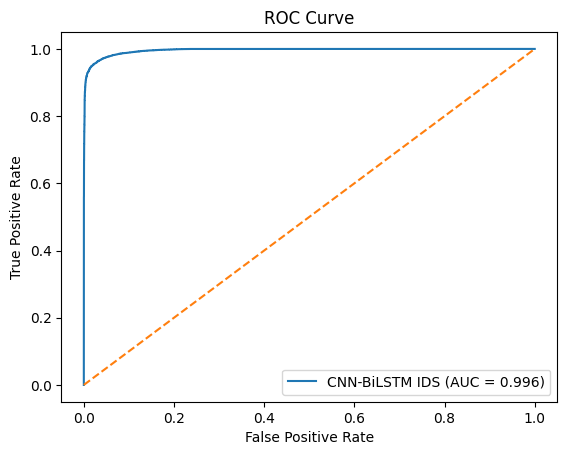

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# prediction probabilities
y_scores = model.predict(X_val).ravel()

# ROC computation
fpr, tpr, thresholds = roc_curve(y_val, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure()

plt.plot(fpr, tpr, label="CNN-BiLSTM IDS (AUC = %0.3f)" % roc_auc)

plt.plot([0,1],[0,1], linestyle="--")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

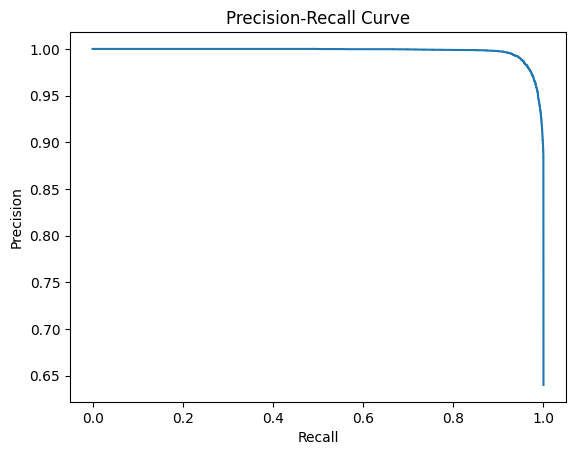

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_val, y_scores)

plt.figure()

plt.plot(recall, precision)

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.show()

938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step


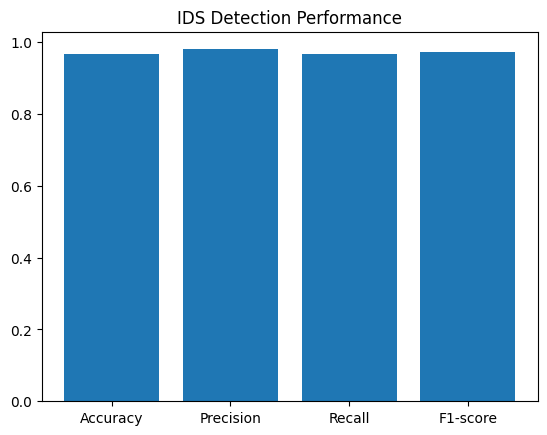

Accuracy: 0.9656
Precision: 0.9800771547851821
Recall: 0.965887193375345
F1-score: 0.9729304375196727


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

y_pred = (model.predict(X_val) > 0.5).astype(int)

accuracy = accuracy_score(y_val,y_pred)
precision = precision_score(y_val,y_pred)
recall = recall_score(y_val,y_pred)
f1 = f1_score(y_val,y_pred)

metrics = ["Accuracy","Precision","Recall","F1-score"]
values = [accuracy,precision,recall,f1]

plt.figure()

plt.bar(metrics,values)

plt.title("IDS Detection Performance")

plt.show()

print("Accuracy:",accuracy)
print("Precision:",precision)
print("Recall:",recall)
print("F1-score:",f1)

In [ ]:
# ==================================
# SECURE COMMUNICATION SIMULATION
# ==================================

import os
import json
import hashlib
import numpy as np
from cryptography.hazmat.primitives.asymmetric import ec
from cryptography.hazmat.primitives.ciphers.aead import AESGCM


# -------- KEY GENERATION --------

def generate_keys():

    sender_private = ec.generate_private_key(ec.SECP256R1())
    receiver_private = ec.generate_private_key(ec.SECP256R1())

    shared_secret = sender_private.exchange(
        ec.ECDH(),
        receiver_private.public_key()
    )

    aes_key = hashlib.sha256(shared_secret).digest()[:16]

    return sender_private, receiver_private, aes_key


# -------- ENCRYPT --------

def encrypt_packet(data, key):

    aes = AESGCM(key)

    nonce = os.urandom(12)

    encrypted = aes.encrypt(nonce, data.encode(), None)

    return nonce, encrypted


# -------- DECRYPT --------

def decrypt_packet(nonce, encrypted, key):

    aes = AESGCM(key)

    decrypted = aes.decrypt(nonce, encrypted, None)

    return decrypted.decode()


# -------- IDS THREAT CHECK --------

def check_threat():

    sample = X_val[np.random.randint(len(X_val))].reshape(1, X_val.shape[1], 1)

    prob = model.predict(sample)[0][0]

    if prob < 0.3:
        level = "LOW"

    elif prob < 0.7:
        level = "MEDIUM"

    else:
        level = "HIGH"

    return prob, level


# ==================================
# INITIAL KEY EXCHANGE
# ==================================

sender_key, receiver_key, aes_key = generate_keys()

print("\nInitial Secure Channel Established")
print("AES Key:", aes_key[:8], "...")

# ==================================
# DATA TRANSMISSION LOOP
# ==================================

for i in range(5):

    print("\n==============================")
    print("Transmission:", i+1)

    data = json.dumps({

        "patient_id": np.random.randint(1000),
        "heart_rate": np.random.randint(60,120),
        "spo2": np.random.randint(92,100)

    })

    print("\nSender Data:", data)

    # encrypt packet
    nonce, encrypted = encrypt_packet(data, aes_key)

    print("\nEncrypted Packet:", encrypted[:60])

    # receiver decrypts FIRST
    decrypted = decrypt_packet(nonce, encrypted, aes_key)

    print("\nReceiver Decrypted Data:", decrypted)

    # IDS threat detection
    prob, level = check_threat()

    print("\nThreat Probability:", round(prob,4))
    print("Threat Level:", level)

    # regenerate key for NEXT communication
    if level == "HIGH":

        print("\n⚠ Cyberattack detected!")
        print("Regenerating encryption keys...")

        sender_key, receiver_key, aes_key = generate_keys()

        print("New AES Key:", aes_key[:8], "...")


Initial Secure Channel Established
AES Key: b'\xe4\xfb\x0c\x9e\x10\x8e\xc5x' ...

Transmission: 1

Sender Data: {"patient_id": 5, "heart_rate": 69, "spo2": 93}

Encrypted Packet: b'\x8dV\xe0\xd1eh\xbc\xce[\x90V|\x9ctSV\xab%\x82`\\&\xa2\x01>\xb52\xd1\xae\x86\x87\xaf\xc7\xff\x9a\x7fp\xc9\xe7\x8ay\xa7\xbd\x95\x0c\xcf\xd9\x89Gk\x82\xd2\xa3m\xee\xc9\x01*z\xe8'

Receiver Decrypted Data: {"patient_id": 5, "heart_rate": 69, "spo2": 93}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

Threat Probability: 1.0
Threat Level: HIGH

⚠ Cyberattack detected!
Regenerating encryption keys...
New AES Key: b'\xaa\xea\xea<\xa3\xc8\xe4n' ...

Transmission: 2

Sender Data: {"patient_id": 205, "heart_rate": 74, "spo2": 97}

Encrypted Packet: b"T\xc0+(\xac.{m\x82^9\x9ex\x14\xabW5\xef\x89)\x87\xc2j\xcc\x00\xde\x08\x14\x89\x85\xa2\xa9xdB)\xfdS'\xda\x98\xc6q\x07\t\xfa\x9e\xa2?\x17N,\xb6\xf7\xb7\x14\x03G\x13\xc0"

Receiver Decrypted Data: {"patient_id": 205, "heart_rate": 74, "spo2": 97}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/st

In [ ]:
!pip install gradio
import gradio as gr
import json
import numpy as np

# initialize secure channel
sender_key, receiver_key, aes_key = generate_keys()


def medshield_send(patient_id, heart_rate, spo2):

    global sender_key, receiver_key, aes_key

    # medical data
    data = json.dumps({
        "patient_id": patient_id,
        "heart_rate": heart_rate,
        "spo2": spo2
    })

    # encrypt
    nonce, encrypted = encrypt_packet(data, aes_key)

    # decrypt
    decrypted = decrypt_packet(nonce, encrypted, aes_key)

    # IDS threat detection
    prob, level = check_threat()

    action = "Normal Encryption"

    if level == "HIGH":

        action = "Key Regeneration"

        sender_key, receiver_key, aes_key = generate_keys()

    elif level == "MEDIUM":

        action = "Stronger Encryption"


    return (
        str(sender_key.public_key()),
        str(receiver_key.public_key()),
        encrypted[:60],
        decrypted,
        round(prob,4),
        level,
        action
    )


ui = gr.Interface(

    fn=medshield_send,

    inputs=[
        gr.Number(label="Patient ID"),
        gr.Number(label="Heart Rate"),
        gr.Number(label="SpO2")
    ],

    outputs=[
        gr.Textbox(label="Sender Public Key"),
        gr.Textbox(label="Receiver Public Key"),
        gr.Textbox(label="Encrypted Packet"),
        gr.Textbox(label="Receiver Decrypted Data"),
        gr.Number(label="Threat Probability"),
        gr.Textbox(label="Threat Level"),
        gr.Textbox(label="Security Action")
    ],

    title="MedShield Secure Medical Communication System",

    description="AI-Controlled Dynamic Encryption with CNN + BiLSTM IDS"
)

ui.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1a12e7a895ff9f2d48.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import gradio as gr
import matplotlib.pyplot as plt
import json
from cryptography.hazmat.primitives import serialization

threat_history = []
previous_key = None


def medshield_dashboard(patient_id, heart_rate, spo2):

    global sender_key, receiver_key, aes_key
    global previous_key, threat_history

    # create medical packet
    packet = json.dumps({
        "patient_id": patient_id,
        "heart_rate": heart_rate,
        "spo2": spo2
    })

    # encrypt
    nonce, encrypted = encrypt_packet(packet, aes_key)

    # decrypt
    decrypted = decrypt_packet(nonce, encrypted, aes_key)

    # IDS prediction
    prob, _ = check_threat()

    threat_history.append(prob)

    # default values
    level = "LOW"
    action = "Normal Encryption"
    alert = "Secure Communication"

    # threat logic
    if prob < 0.3:

        level = "LOW"
        action = "Normal Encryption"
        alert = "Secure Communication"

    elif prob < 0.7:

        level = "MEDIUM"
        action = "Stronger Encryption"
        alert = "⚠ Suspicious Network Activity"

    else:

        level = "HIGH"

        previous_key = aes_key

        sender_key, receiver_key, aes_key = generate_keys()

        action = "🚨 Key Regeneration"
        alert = "🚨 Cyber Attack Detected"

    # public keys
    sender_pub = sender_key.public_key().public_bytes(
        encoding=serialization.Encoding.PEM,
        format=serialization.PublicFormat.SubjectPublicKeyInfo
    ).decode()

    receiver_pub = receiver_key.public_key().public_bytes(
        encoding=serialization.Encoding.PEM,
        format=serialization.PublicFormat.SubjectPublicKeyInfo
    ).decode()

    # threat graph
    plt.figure()

    plt.plot(threat_history)

    plt.ylim(0, 1)

    plt.title("Threat Probability Trend")

    plt.xlabel("Transmission")

    plt.ylabel("Threat Probability")

    graph = plt.gcf()

    return (
        sender_pub,
        receiver_pub,
        str(previous_key),
        str(aes_key),
        encrypted[:80],
        decrypted,
        round(prob, 4),
        level,
        action,
        alert,
        graph
    )


with gr.Blocks(title="MedShield Security Dashboard") as ui:

    gr.Markdown(
    """
    # 🛡 MedShield Cybersecurity Dashboard
    AI Controlled Dynamic Encryption for Secure Medical Communication
    CNN + BiLSTM Intrusion Detection System
    """
    )

    with gr.Row():

        with gr.Column():

            gr.Markdown("### Medical Sensor Input")

            patient_id = gr.Number(label="Patient ID")

            heart_rate = gr.Number(label="Heart Rate")

            spo2 = gr.Number(label="SpO2")

            send_btn = gr.Button("Transmit Secure Packet")

        with gr.Column():

            gr.Markdown("### Threat Detection")

            threat_prob = gr.Slider(0, 1, label="Threat Probability")

            threat_level = gr.Textbox(label="Threat Level")

            action = gr.Textbox(label="Security Action")

            alert_box = gr.Textbox(label="Security Alert")

    gr.Markdown("### Encryption Engine")

    with gr.Row():

        sender_pub = gr.Textbox(label="Sender Public Key")

        receiver_pub = gr.Textbox(label="Receiver Public Key")

    with gr.Row():

        prev_key = gr.Textbox(label="Previous AES Key")

        current_key = gr.Textbox(label="Current AES Key")

    encrypted = gr.Textbox(label="Encrypted Packet")

    decrypted = gr.Textbox(label="Receiver Decrypted Data")

    gr.Markdown("### Threat Monitoring")

    threat_graph = gr.Plot()

    send_btn.click(
        medshield_dashboard,
        inputs=[patient_id, heart_rate, spo2],
        outputs=[
            sender_pub,
            receiver_pub,
            prev_key,
            current_key,
            encrypted,
            decrypted,
            threat_prob,
            threat_level,
            action,
            alert_box
        ]
    )

ui.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://58f01ad6f054d7a7d8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import gradio as gr

css = """
body {
    background-color:#0f172a;
    color:white;
}

#title{
    text-align:center;
    font-size:32px;
    font-weight:bold;
    color:#38bdf8;
}

.panel{
    background:#1e293b;
    padding:20px;
    border-radius:12px;
    box-shadow:0px 0px 10px rgba(0,0,0,0.5);
}

.green{
    color:#22c55e;
    font-weight:bold;
}

.yellow{
    color:#facc15;
    font-weight:bold;
}

.red{
    color:#ef4444;
    font-weight:bold;
}
"""

with gr.Blocks(css=css,title="MedShield Dashboard") as ui:

    gr.Markdown("<div id='title'>🛡 MedShield Secure Medical Communication</div>")

    with gr.Row():

        with gr.Column(elem_classes="panel"):

            gr.Markdown("### 🧬 Medical Sensor Input")

            patient_id=gr.Number(label="Patient ID")

            heart_rate=gr.Number(label="Heart Rate")

            spo2=gr.Number(label="SpO2")

            send_btn=gr.Button("🚀 Transmit Secure Packet")

        with gr.Column(elem_classes="panel"):

            gr.Markdown("### 🧠 Intrusion Detection")

            threat_prob=gr.Slider(0,1,label="Threat Probability")

            threat_level=gr.Textbox(label="Threat Level")

            action=gr.Textbox(label="Security Action")

            alert_box=gr.Textbox(label="Security Alert")

    with gr.Row():

        with gr.Column(elem_classes="panel"):

            gr.Markdown("### 🔑 ECDH Secure Channel")

            sender_pub=gr.Textbox(label="Sender Public Key")

            receiver_pub=gr.Textbox(label="Receiver Public Key")

        with gr.Column(elem_classes="panel"):

            gr.Markdown("### 🔐 AES Encryption Engine")

            prev_key=gr.Textbox(label="Previous AES Key")

            current_key=gr.Textbox(label="Current AES Key")

    with gr.Row():

        with gr.Column(elem_classes="panel"):

            gr.Markdown("### 📦 Packet Transmission")

            encrypted=gr.Textbox(label="Encrypted Packet")

            decrypted=gr.Textbox(label="Receiver Decrypted Data")

    with gr.Row():

        with gr.Column(elem_classes="panel"):

            gr.Markdown("### 📊 Threat Monitoring")

            threat_graph=gr.Plot()

    send_btn.click(
        medshield_dashboard,
        inputs=[patient_id,heart_rate,spo2],
        outputs=[
            sender_pub,
            receiver_pub,
            prev_key,
            current_key,
            encrypted,
            decrypted,
            threat_prob,
            threat_level,
            action,
            alert_box
        ]
    )

ui.launch()

/tmp/ipykernel_339/1776459978.py:39: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=css,title="MedShield Dashboard") as ui:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://abce7c17e84c0bbfee.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
